# <font color=darkred>Laboratory 23: Regression Models </font>

In [1]:
#### Preamble script block to identify host, user, and kernel
import sys
! hostname
! whoami
print(sys.executable)
print(sys.version)
print(sys.version_info)

GouldPC
gouldpc\gould
C:\Users\gould\anaconda3\python.exe
3.12.4 | packaged by Anaconda, Inc. | (main, Jun 18 2024, 15:03:56) [MSC v.1929 64 bit (AMD64)]
sys.version_info(major=3, minor=12, micro=4, releaselevel='final', serial=0)


#### Full name: Graysen Gould
## R#: 11944656
## Title of the notebook: Lab 23: regression Models
## Date: 12-3-24

### Let's go over some important terminology:

    Linear Regression:
    a basic predictive analytics technique that uses historical data to predict an output variable.

    The Predictor variable (input):
    the variable(s) that help predict the value of the output variable. It is commonly referred to as X.
    
    The Output variable:
    the variable that we want to predict. It is commonly referred to as Y.
    
#### To estimate Y using linear regression, we assume the equation: $Ye = βX + α$
*where Yₑ is the estimated or predicted value of Y based on our linear equation.* <br>

#### Our goal is to find statistically significant values of the parameters α and β that minimise the difference between Y and Yₑ. If we are able to determine the optimum values of these two parameters, then we will have the line of best fit that we can use to predict the values of Y, given the value of X. <br>

## So, how do we estimate α and β? <br>
![](https://media3.giphy.com/media/EijsQdawZkiqY/200.gif) <br>

#### We can use a method called Ordinary Least Squares (OLS). <br>
![](https://miro.medium.com/max/338/1*VVA0rF6MWXcw1JmRNFA87g.png) <br>

#### The objective of the least squares method is to find values of α and β that minimise the sum of the squared difference between Y and Yₑ (distance between the linear fit and the observed points). We will not go through the derivation here, but using calculus we can show that the values of the unknown parameters are as follows: <br>
![](https://miro.medium.com/max/222/0*gR-W7RFar9ijxwAa) <br>
#### where X̄ is the mean of X values and Ȳ is the mean of Y values. β is simply the covariance of X and Y (Cov(X, Y)  devided by the variance of X (Var(X)). <br>

#### Example - Using the table of recoded times and speeds from some experimental observations:

|Elapsed Time (s)|Speed (m/s)|
|---:|---:|
|0 |0|
|1.0 |3|
|2.0 |7|
|3.0 |12|
|4.0 |20|
|5.0 |30|
|6.0 | 45.6| 
|7.0 | 60.3 |
|8.0 | 77.7 |
|9.0 | 97.3 |
|10.0| 121.1|

In [2]:
# Load the necessary packages
import numpy as np
import pandas as pd
import statistics 
from matplotlib import pyplot as plt

# Create a dataframe:
time = [0, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0]
speed = [0, 3, 7, 12, 20, 30, 45.6, 60.3, 77.7, 97.3, 121.2]
data = pd.DataFrame({'Time':time, 'Speed':speed})
time_var = statistics.variance(time)
speed_var = statistics.variance(speed)

print("Variance of recorded times is ",time_var)
print("Variance of recorded speed is ",speed_var)
# To find the covariance  
data.cov() 

Variance of recorded times is  11.0
Variance of recorded speed is  1697.776


,Time,Speed
Time,11.00,131.750
Speed,131.75,1697.776


# Linear Regression with primitive Python:
#### To estimate "y" using the OLS method, we need to calculate "xmean" and "ymean", the covariance of X and y ("xycov"), and the variance of X ("xvar") before we can determine the values for alpha and beta. In our case, X is time and y is Speed.

In [3]:
# Calculate the mean of X and y
xmean = np.mean(time)
ymean = np.mean(speed)

# Calculate the terms needed for the numator and denominator of beta
data['xycov'] = (data['Time'] - xmean) * (data['Speed'] - ymean)
data['xvar'] = (data['Time'] - xmean)**2

# Calculate beta and alpha
beta = data['xycov'].sum() / data['xvar'].sum()
alpha = ymean - (beta * xmean)
print(f'alpha = {alpha}')
print(f'beta = {beta}')


alpha = -16.78636363636363
beta = 11.977272727272727


In [4]:
#### We now have an estimate for alpha and beta! Our model can be written as Yₑ = 11.977 X -16.786, and we can make predictions:
X = np.array(time)
ypred = alpha + beta * X
print(ypred)

[-16.78636364  -4.80909091   7.16818182  19.14545455  31.12272727
  43.1         55.07727273  67.05454545  79.03181818  91.00909091
 102.98636364]


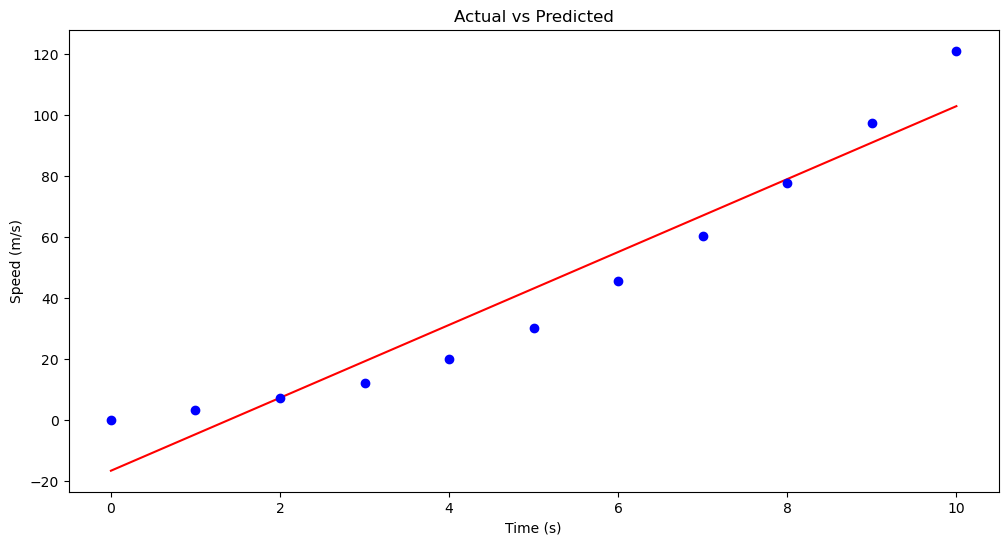

In [5]:
### Let’s plot our prediction ypred against the actual 
# Plot regression against actual data
plt.figure(figsize=(12, 6))
plt.plot(X, ypred, color="red")     # regression line
plt.plot(time, speed, 'bo')   # scatter plot showing actual data
plt.title('Actual vs Predicted')
plt.xlabel('Time (s)')
plt.ylabel('Speed (m/s)')
plt.show()

#### The red line is our line of best fit, Yₑ = 11.977 X -16.786. We can see from this graph that there is a positive linear relationship between X and y. Using our model, we can predict y from any values of X! 
#### For example, if we had a value X = 20, we can predict that:

In [6]:
ypred_20 = alpha + beta * 20
print(ypred_20)

222.7590909090909


# Linear Regression with Statsmodels:
#### First, we use statsmodels’ ols function to initialise our simple linear regression model. This takes the formula y ~ X, where X is the predictor variable (Time) and y is the output variable (Speed). Then, we fit the model by calling the OLS object’s fit() method.

In [7]:
import statsmodels.formula.api as smf
# Initialise and fit linear regression model using `statsmodels`
model = smf.ols('Speed ~ Time', data=data)
model = model.fit()
model.params  #We no longer have to calculate alpha and beta ourselves. Calling model.params will show us the model’s parameters

Intercept   -16.786364
Time         11.977273
dtype: float64

#### In the notation that we have been using, α is the intercept and β is the slope i.e. α =-16.786364 and β = 11.977273.


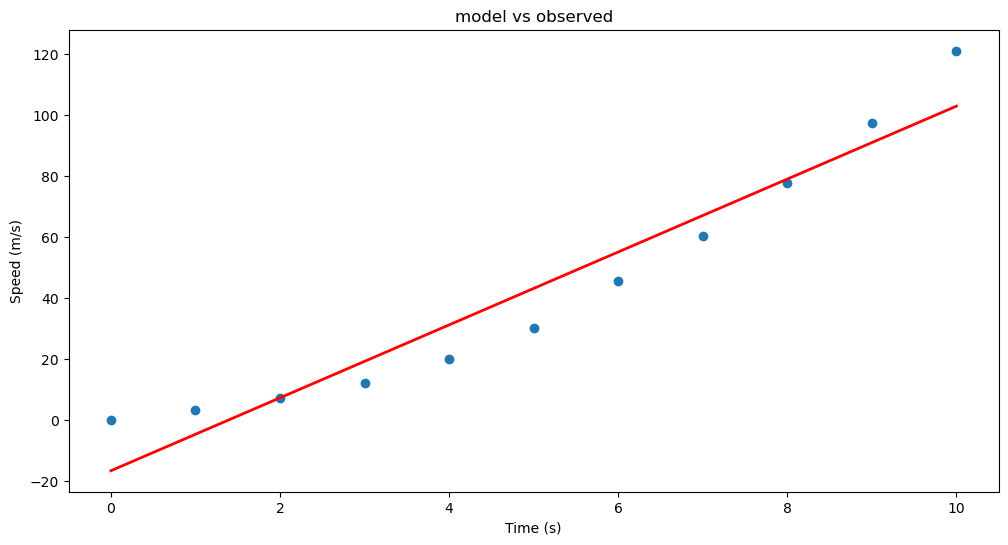

In [8]:
# Predict values
speed_pred = model.predict()
# Plot regression against actual data
plt.figure(figsize=(12, 6))
plt.plot(data['Time'], data['Speed'], 'o')           # scatter plot showing actual data
plt.plot(data['Time'], speed_pred, 'r', linewidth=2)   # regression line
plt.xlabel('Time (s)')
plt.ylabel('Speed (m/s)')
plt.title('model vs observed')
plt.show()

In [9]:
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  Speed   R-squared:                       0.929
Model:                            OLS   Adj. R-squared:                  0.922
Method:                 Least Squares   F-statistic:                     118.6
Date:                Tue, 03 Dec 2024   Prob (F-statistic):           1.75e-06
Time:                        18:16:43   Log-Likelihood:                -41.405
No. Observations:                  11   AIC:                             86.81
Df Residuals:                       9   BIC:                             87.61
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    -16.7864      6.507     -2.580      0.0

C:\Users\gould\anaconda3\Lib\site-packages\scipy\stats\_axis_nan_policy.py:531: UserWarning: kurtosistest only valid for n>=20 ... continuing anyway, n=11
  res = hypotest_fun_out(*samples, **kwds)


# Linear Regression with sklearn package

In [10]:
!pip install scikit-learn

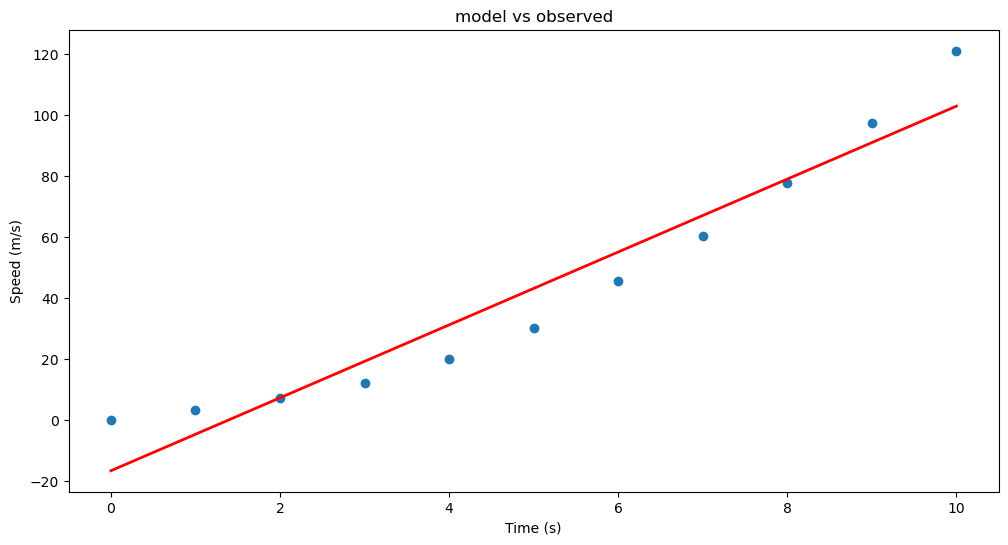

In [11]:
from sklearn.linear_model import LinearRegression
# Initialise and fit model
lm = LinearRegression()
lm.fit(data[['Time']],data['Speed'])
prediction = lm.predict(data[['Time']])
# Plot regression against actual data
plt.figure(figsize=(12, 6))
plt.plot(data['Time'], data['Speed'], 'o')           # scatter plot showing actual data
plt.plot(data['Time'], prediction, 'r', linewidth=2)   # regression line
plt.xlabel('Time (s)')
plt.ylabel('Speed (m/s)')
plt.title('model vs observed')
plt.show()

In [12]:
from sklearn.metrics import mean_squared_error, r2_score
# Mean Squared Error
mse = mean_squared_error(data['Speed'], prediction)
# Root Mean Squared Error (RMSE)
rmse = np.sqrt(mse)
# R-squared
r2 = r2_score(data['Speed'], prediction)

#Print the summary
print("Linear Regression Model Summary:")
print("---------------------------------")
print(f"Coefficients or betas: {lm.coef_}")
print(f"Intercept or alpha: {lm.intercept_}")
print(f"Mean Squared Error (MSE): {mse}")
print(f"Root Mean Squared Error (RMSE): {rmse}")
print(f"R-squared (R²): {r2}")

Linear Regression Model Summary:
---------------------------------
Coefficients or betas: [11.97727273]
Intercept or alpha: -16.786363636363667
Mean Squared Error (MSE): 108.88210743801652
Root Mean Squared Error (RMSE): 10.434658951686755
R-squared (R²): 0.9294545816516324


## Exercise 23.0: Advertising and Sells! (50 Marks)
This is a classic regression problem. we have a dataset of the spendings on TV, Radio, and Newspaper advertisements and number of sales for a specific product. We are interested in exploring the relationship between these parameters and answering the questions below. You can download the dataset by running the cell below 

In [13]:
import requests # Module to process http/https requests
remote_url="http://54.243.252.9/engr-1330-webroot/4-Databases/Advertising.csv"  # set the url
rget = requests.get(remote_url, allow_redirects=True)  # get the remote resource, follow imbedded links
open('Advertising.csv','wb').write(rget.content); # extract from the remote the contents, assign to a local file same name

1. Read the file, show the statistical summary, the correlation and the covariance.

In [14]:
# Import and display first rows of the advertising dataset
advertising = pd.read_csv("Advertising.csv")

advertising.head(5)

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


In [15]:
# Describe the df
display(advertising.describe()) # describe statistical features of data

,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000
mean,147.042500,23.264000,30.554000,14.022500
std,85.854236,14.846809,21.778621,5.217457
min,0.700000,0.000000,0.300000,1.600000
25%,74.375000,9.975000,12.750000,10.375000
50%,149.750000,22.900000,25.750000,12.900000
75%,218.825000,36.525000,45.100000,17.400000
max,296.400000,49.600000,114.000000,27.000000


In [19]:
# Get Variance and Covariance - What can we infer?
print(advertising.var()) # get the variance of all 4 columns
print(advertising.cov()) # get all covariances


# From the variances, we can see that TV has the highest variance, and Sales has the lowest variance in values.
# We cannot tell much from the covariance because of the various scales. However, what we can tell is that none of the values are negatively correlated.

TV           7370.949893
Radio         220.427743
Newspaper     474.308326
Sales          27.221853
dtype: float64
                    TV       Radio   Newspaper       Sales
TV         7370.949893   69.862492  105.919452  350.390195
Radio        69.862492  220.427743  114.496979   44.635688
Newspaper   105.919452  114.496979  474.308326   25.941392
Sales       350.390195   44.635688   25.941392   27.221853


In [22]:
# Get Correlation Coefficient - What can we infer?
advertising.corr()

# From this data we can tell that the TV column has the greatest correlation with sales, whereas the newspaper column has the lowest correlation 
# with sales.

,TV,Radio,Newspaper,Sales
TV,1.000000,0.054809,0.056648,0.782224
Radio,0.054809,1.000000,0.354104,0.576223
Newspaper,0.056648,0.354104,1.000000,0.228299
Sales,0.782224,0.576223,0.228299,1.000000


2. Use the statsmodels library and determine if TV advertising spending can predict the number of sales for the product?
  Create a regression plot to compare the predicted number of sales based on TV advertising spending with the actual sales numbers.

In [145]:
# Answer the first question: Can TV advertising spending predict the number of sales for the product?
import statsmodels.formula.api as smf

# create and train model
model = smf.ols("Sales ~ TV", advertising)
model = model.fit()

# create predictions based on model
y_pred = model.predict()

print(model.params) # show model slope and intercept

Intercept    7.032594
TV           0.047537
dtype: float64


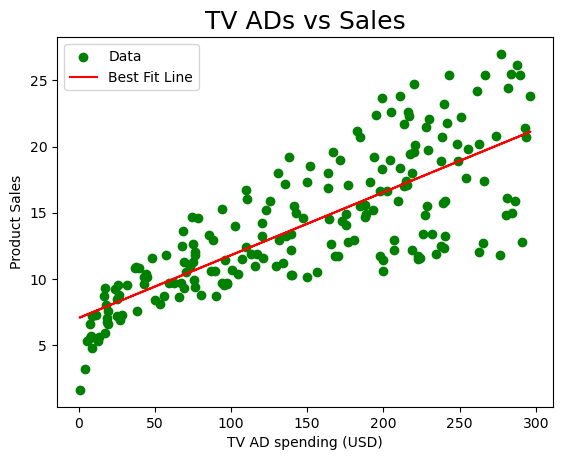

In [144]:
# Plot regression against actual data - What do we see?
import matplotlib.pyplot as plt

plt.scatter(advertising["TV"], advertising["Sales"], color = "green", label = "Data") # plot original data

plt.plot(advertising["TV"], y_pred, color = "red", label = "Best Fit Line") # plot best fit line

plt.title("TV ADs vs Sales", fontsize = 18)
plt.xlabel("TV AD spending (USD)")
plt.ylabel("Product Sales")


plt.legend()
plt.show()


In [146]:
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  Sales   R-squared:                       0.612
Model:                            OLS   Adj. R-squared:                  0.610
Method:                 Least Squares   F-statistic:                     312.1
Date:                Tue, 03 Dec 2024   Prob (F-statistic):           1.47e-42
Time:                        19:54:47   Log-Likelihood:                -519.05
No. Observations:                 200   AIC:                             1042.
Df Residuals:                     198   BIC:                             1049.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      7.0326      0.458     15.360      0.000       6.130       7.935
TV             0.0475      0.003     17.668      0.000       0.042       0.053
==============================================================================
Omnibus:                        0.531   Durbin-Watson:                   1.935
Prob(Omnibus):                  0.767   Jarque-Bera (JB):                0.669
Skew:                          -0.089   Prob(JB):                        0.716
Kurtosis:                       2.779   Cond. No.                         338.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

3. Without using regression libraries determine if Radio advertising spending can predict the number of sales for the product? Create a regression plot to compare the predicted number of sales based on Radio advertising spending with the actual sales numbers.

In [142]:
# Radio Ads vs sales
x = np.array(advertising["Radio"])
y = np.array(advertising["Sales"])

# find variance and covariance
xy_cov = ((x - x.mean()) * ( y - y.mean())).sum() / len(x)
x_var = ((x - x.mean())**2).sum() / len(x)

# find alpha and beta 
beta = xy_cov / x_var
alpha = y.mean() - beta*x.mean()

# create model
model = lambda x: beta*x + alpha

# calculate estimated y values
y_pred = model(x)


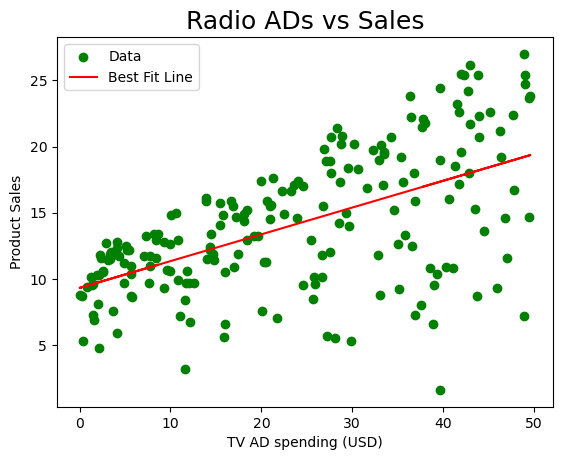

In [71]:
# plotting model
import matplotlib.pyplot as plt

plt.scatter(x, y, color = "green", label = "Data") # plot original data

plt.plot(x, y_pred, color = "red", label = "Best Fit Line") # plot best fit line

plt.title("Radio ADs vs Sales", fontsize = 18)
plt.xlabel("TV AD spending (USD)")
plt.ylabel("Product Sales")


plt.legend()
plt.show()

In [76]:
# evaluate model
sors = ((y - y_pred)**2).sum() # sum of residual squares
tsos = ((y - y.mean())**2).sum() # total sum of squares

r2 = 1 - sors / tsos
print(f" our r squared value is: {round(r2, 5)}")

# we can see that our model does not fit the data very well

 our r squared value is: 0.33203


4. Use the sklearn library and determine if newspaper advertising spending can predict the number of sales for the product? Create a regression plot to compare the predicted number of sales based on newspaper advertising spending with the actual sales numbers.

In [78]:
advertising.head()

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


In [85]:
from sklearn.linear_model import LinearRegression

x = np.array(advertising["Newspaper"])
y = np.array(advertising["Sales"])


model = LinearRegression()

model.fit(advertising[["Newspaper"]],advertising["Sales"])

y_pred = model.predict(advertising[["Newspaper"]])

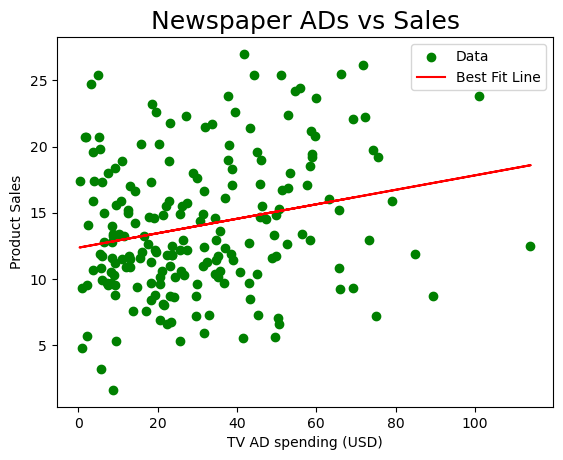

In [87]:
plt.scatter(advertising["Newspaper"], advertising["Sales"], color = "green", label = "Data") # plot original data

plt.plot(advertising["Newspaper"], y_pred, color = "red", label = "Best Fit Line") # plot best fit line

plt.title("Newspaper ADs vs Sales", fontsize = 18)
plt.xlabel("TV AD spending (USD)")
plt.ylabel("Product Sales")


plt.legend()
plt.show()

5. Calcuate the Mean Squared Error (MSE), Root Mean Squared Error (RMSE) and R-squared for predictions using TV, Radio and Newspaper. Which parameter is a better predictor of the number of sales for the product?

In [91]:
from sklearn.metrics import mean_squared_error, r2_score

MSE = mean_squared_error(advertising["Sales"], y_pred)
RMSE = np.sqrt(MSE)
r2 = r2_score(advertising["Sales"], y_pred)
print(f" MSE: {round(MSE, 4)}, RMSE: {round(RMSE, 4)}, r^2: {round(r2, 4)}")

# the r^2 value is the best indicator of model fit, as it is consitant across datasets
# from the r^2 value, we can see that our model is a very poor predictor of sales


 MSE: 25.674, RMSE: 5.067, r^2: 0.0521


___
## Multiple regression
Multiple regression is a statistical technique used to understand the relationship between one dependent variable and two or more independent variables. It helps determine how changes in the independent variables affect the dependent variable, and it is a key tool in predictive modeling.

### The General Form
The equation for multiple regression is:

$$
Y = \beta_0 + \beta_1 X_1 + \beta_2 X_2 + \dots + \beta_n X_n + \epsilon
$$

Where:
- \( Y \) is the dependent variable (the outcome we are trying to predict).
- \( $X_1, X_2, \dots, X_n $\) are the independent variables (predictors).
- \( $\beta_0 $\) is the intercept (the value of \( Y \) when all \( X \)'s are 0).
- \( $\beta_1, \beta_2, \dots, \beta_n$ \) are the coefficients (indicating the effect of each predictor on \( Y \)).
- \($ \epsilon$ \) is the error term (the unexplained variation).

### Key Assumptions
Multiple regression makes several assumptions:
1. **Linearity**: The relationship between the independent variables and the dependent variable is linear.
2. **Independence**: Observations are independent of each other.
3. **Homoscedasticity**: The variance of residuals (errors) is constant.
4. **No multicollinearity**: Independent variables are not highly correlated with each other.
5. **Normality of residuals**: The residuals should be normally distributed.

### Use Cases
- Predicting sales based on advertising spend across different channels (e.g., TV, radio, and online).
- Estimating housing prices based on features like size, location, and number of rooms.

Would you like an example with code or further details on any of these points?
## Example
Here we will explore the data set [heart.data.csv](http://54.243.252.9/engr-1330-webroot/8-Labs/Lab29/heart.data.csv) and determine the effect that the independent variables biking and smoking have on the dependent variable heart disease using a multiple linear regression model in the statsmodels library.

In [93]:
# Load the necessary packages
import numpy as np
import pandas as pd
import statistics 
import math
from matplotlib import pyplot as plt
import statsmodels.formula.api as smf

In [94]:
# Download the file
import requests # Module to process http/https requests
remote_url="http://54.243.252.9/engr-1330-webroot/8-Labs/Lab29/heart.data.csv"  # set the url
rget = requests.get(remote_url, allow_redirects=True)  # get the remote resource, follow imbedded links
open('heart.data.csv','wb').write(rget.content); # extract from the remote the contents, assign to a local file same name

Read into a dataframe. The database original source \@ [https://www.scribbr.com/statistics/multiple-linear-regression/](https://www.scribbr.com/statistics/multiple-linear-regression/) does not report the units on each variable, a good guess is **biking** is miles per week, **smoking** is packs per week, and **heart.disease** is possibly hospital admissions per 100000 for coronary complications.


After the read we need some shenigagins to get the column names meaningful.

In [95]:
heartattack = pd.read_csv('heart.data.csv')
data = heartattack.rename(columns={"biking":"Bike","smoking":"Smoke","heart.disease":"Disease"})
data.head(3)

,Unnamed: 0,Bike,Smoke,Disease
0,1,30.801246,10.896608,11.769423
1,2,65.129215,2.219563,2.854081
2,3,1.959665,17.588331,17.177803


### Define the Model Formula

Use the formula notation to define the dependent and independent variables. For example:

```python
formula = 'Disease ~ Bike + Smoke'
```

- The **dependent variable** (the one you're trying to predict) goes on the **left-hand side**.
- The **independent variables** (predictors) are on the **right-hand side** of the tilde (`~`).

In [96]:
#Now build a linear model
# Initialise and fit linear regression model using `statsmodels`
model = smf.ols('Disease ~ Bike + Smoke', data=data)
model = model.fit()  # Fit the model
print(model.params)

Intercept    14.984658
Bike         -0.200133
Smoke         0.178334
dtype: float64


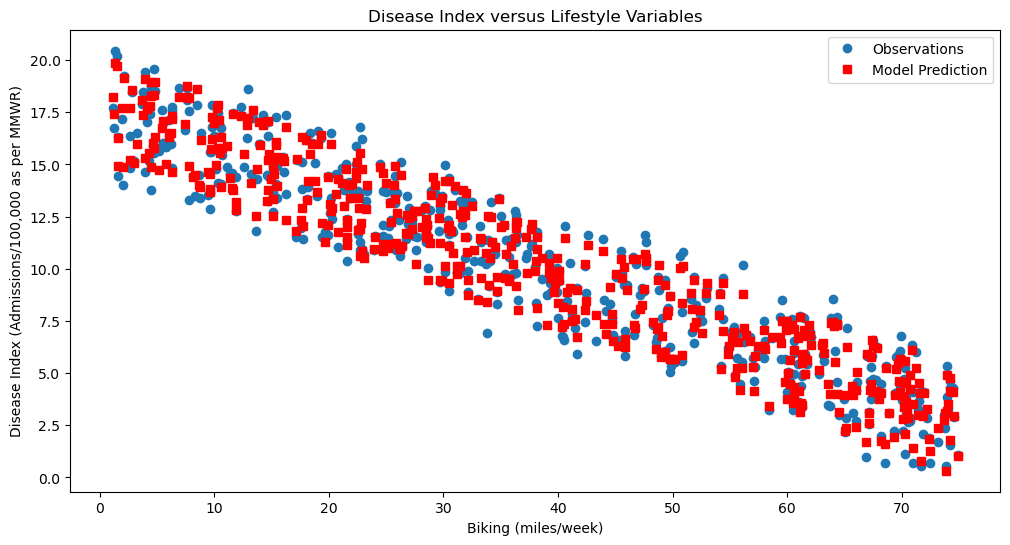

In [99]:
# Predict values
heartfail = model.predict()
titleline = "Disease Index versus Lifestyle Variables"
# Plot regression against actual data - What do we see?
plt.figure(figsize=(12, 6))
plt.plot(data['Bike'], data['Disease'], 'o')           # scatter plot showing actual data
plt.plot(data['Bike'], heartfail, marker = 's' ,color ='r', linewidth=0)   # regression line
plt.xlabel('Biking (miles/week)')
plt.ylabel('Disease Index (Admissions/100,000 as per MMWR)')
plt.legend(['Observations','Model Prediction'])
plt.title(titleline)

plt.show()

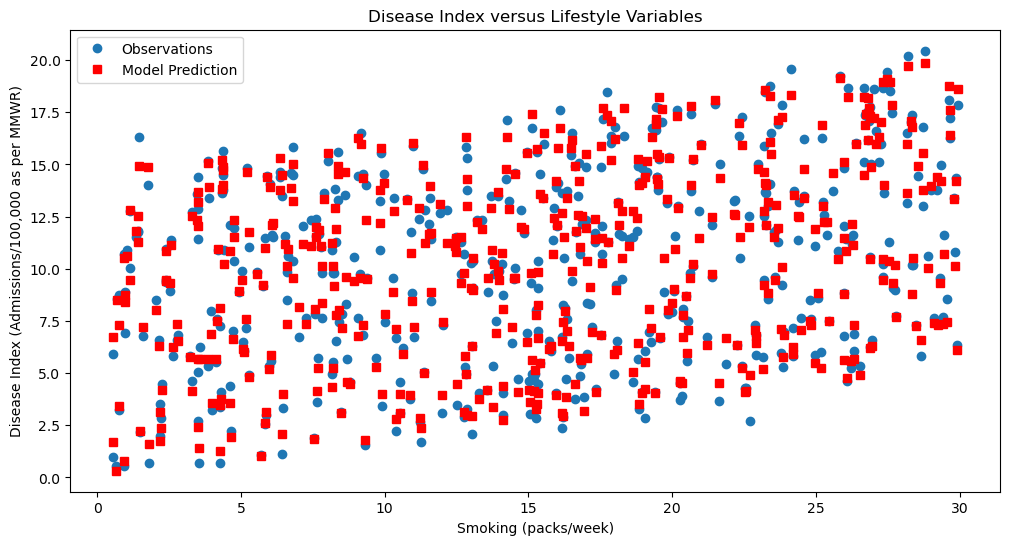

In [100]:
titleline = 'Disease Index versus Lifestyle Variables'
# Plot regression against actual data - What do we see?
plt.figure(figsize=(12, 6))
plt.plot(data['Smoke'], data['Disease'], 'o')           # scatter plot showing actual data
plt.plot(data['Smoke'], heartfail, marker = 's' ,color ='r', linewidth=0)   # regression line
plt.xlabel('Smoking (packs/week)')
plt.ylabel('Disease Index (Admissions/100,000 as per MMWR)')
plt.legend(['Observations','Model Prediction'])
plt.title(titleline)

plt.show()

In [101]:
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                Disease   R-squared:                       0.980
Model:                            OLS   Adj. R-squared:                  0.980
Method:                 Least Squares   F-statistic:                 1.190e+04
Date:                Tue, 03 Dec 2024   Prob (F-statistic):               0.00
Time:                        19:19:33   Log-Likelihood:                -493.68
No. Observations:                 498   AIC:                             993.4
Df Residuals:                     495   BIC:                             1006.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     14.9847      0.080    186.988      0.0

## Step-by-Step Process in Linear Regression
 - Import Necessary Libraries
 - Load and Prepare Data
 - Split Data into Training and Testing Sets
 - Fit a Linear Regression Model
 - Evaluate the Model
 - Make Predictions on Test Data
 - Interpret Results

In [34]:
# Full solution using the statsmodel.api with data Splitting
import pandas as pd
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# Define dependent and independent variables
X = data[['Bike', 'Smoke']]  # Independent variables
y = data['Disease']  # Dependent variable

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42) #here testing is 20% and training is 80%

# Add a constant (intercept) to the independent variables
X_train_const = sm.add_constant(X_train)

# Fit the model
model = sm.OLS(y_train, X_train_const)  # OLS model
result = model.fit()  # Fit the model
# Add constant to the test set and make predictions
X_test_const = sm.add_constant(X_test)
y_pred = result.predict(X_test_const)

# Evaluate the model on test data
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f'Mean Squared Error: {mse}')
print(f'R-squared: {r2}')

# Summary of the model
print(result.summary())

Mean Squared Error: 0.45224798191080295
R-squared: 0.9751106638392245
                            OLS Regression Results                            
Dep. Variable:                Disease   R-squared:                       0.981
Model:                            OLS   Adj. R-squared:                  0.980
Method:                 Least Squares   F-statistic:                     9943.
Date:                Wed, 18 Sep 2024   Prob (F-statistic):               0.00
Time:                        05:10:00   Log-Likelihood:                -391.48
No. Observations:                 398   AIC:                             789.0
Df Residuals:                     395   BIC:                             800.9
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------

### Exercise 23.1  (50 marks)

1. Use Sklearn Library and multilinear regression and repeat the example above.

In [111]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression

# get data and take a look
heartattack = pd.read_csv('heart.data.csv')
heartattack = heartattack.rename(columns={"biking":"Bike","smoking":"Smoke","heart.disease":"Disease"})
heartattack.head()

,Unnamed: 0,Bike,Smoke,Disease
0,1,30.801246,10.896608,11.769423
1,2,65.129215,2.219563,2.854081
2,3,1.959665,17.588331,17.177803
3,4,44.800196,2.802559,6.816647
4,5,69.428454,15.974505,4.062224


In [112]:
# split data
X = heartattack[["Bike", "Smoke"]]
y = heartattack["Disease"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [113]:
#train model
model = LinearRegression()
model.fit(X_train, y_train)

# predict values
y_pred = model.predict(X_test)

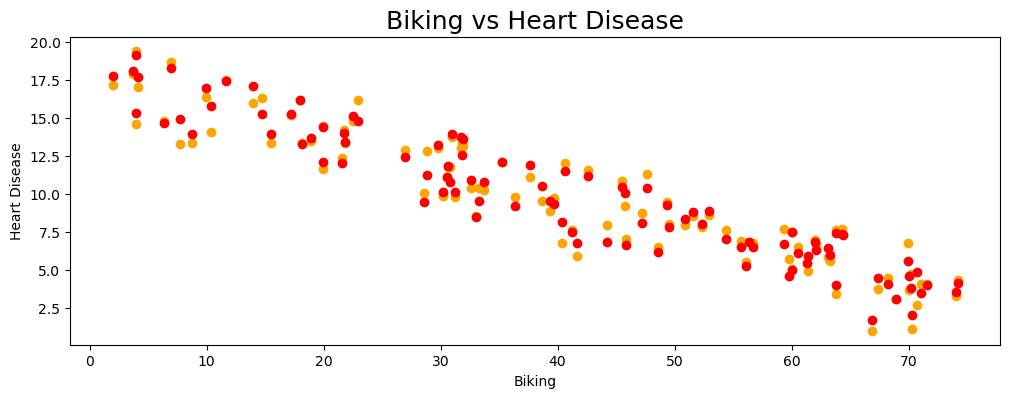

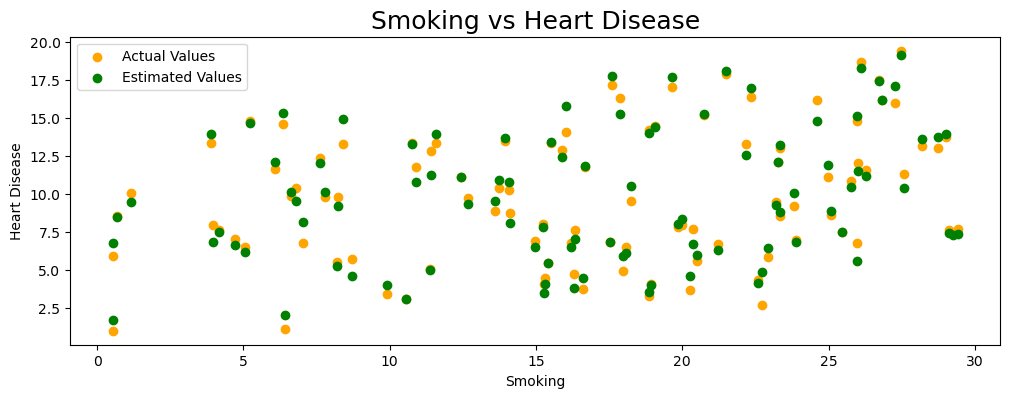

In [126]:
# take a look at prediction
plt.figure(figsize = (12,4))
plt.scatter(X_test["Bike"], y_test, color = "orange", label = "Actual Values")
plt.scatter(X_test["Bike"], y_pred, color = "red", label = "Estimated Values")

plt.title("Biking vs Heart Disease", fontsize = 18)
plt.xlabel("Biking")
plt.ylabel("Heart Disease")

# plot smoking vs heart disease
plt.figure(figsize = (12,4))
plt.scatter(X_test["Smoke"], y_test, color = "orange", label = "Actual Values")
plt.scatter(X_test["Smoke"], y_pred, color = "green", label = "Estimated Values")

plt.title("Smoking vs Heart Disease", fontsize = 18)
plt.xlabel("Smoking")
plt.ylabel("Heart Disease")

plt.legend()
plt.show()

In [131]:
r2 = r2_score(y_test, y_pred)

MSE = mean_squared_error(y_test, y_pred)
RMSE = np.sqrt(MSE)

print(f"MSE: {round(MSE, 4)}, RMSE: {round(RMSE, 4)}, r^2: {round(r2, 4)}")

MSE: 0.4522, RMSE: 0.6725, r^2: 0.9751


In [ ]:
# Because the r^2 value is so high, it shows that this model is a very good predcitor of heart disease

2. The dataset downloadable below shows the spendings on TV, Radio, and Newspaper advertisements and number of sales for a specific product. Use Sklearn Library and multilinear regression on the data to buy a prediction model.

In [147]:
import requests # Module to process http/https requests
remote_url="http://54.243.252.9/engr-1330-webroot/4-Databases/Advertising.csv"  # set the url
rget = requests.get(remote_url, allow_redirects=True)  # get the remote resource, follow imbedded links
open('Advertising.csv','wb').write(rget.content); # extract from the remote the contents, assign to a local file same name

In [148]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression

# get data and take a look
advertising = pd.read_csv('Advertising.csv')
advertising.head()

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


In [149]:
# split data
X = advertising[["TV", "Radio", "Newspaper"]]
y = advertising["Sales"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [150]:
#train model
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

3. Make predictions using the Model

In [151]:
y_pred = model.predict(X_test)

4. Calculate the Mse, Rmse and R2.  

In [152]:
r2 = r2_score(y_test, y_pred)

MSE = mean_squared_error(y_test, y_pred)
RMSE = np.sqrt(MSE)

print(f"MSE: {round(MSE, 4)}, RMSE: {round(RMSE, 4)}, r^2: {round(r2, 4)}")

MSE: 3.1741, RMSE: 1.7816, r^2: 0.8994


5. Compare the models performance when using multilinear regression and univariate regression. what do you Observe.

In [153]:
# The three values we got from univariate regression were: 0.612, 0.332, and 0.0521
# compared to these values, an r^2 value of 0.899 is very good! Multilinear regression is much better than univariate regression

___
![](https://media2.giphy.com/media/5nj4ZZWl6QwneEaBX4/source.gif) <br>

*This notebook was inspired by several blogposts including:*
- __"Introduction to Linear Regression in Python"__ by __Lorraine Li__ available at* https://towardsdatascience.com/introduction-to-linear-regression-in-python-c12a072bedf0 <br>
- __"In Depth: Linear Regression"__ available at* https://jakevdp.github.io/PythonDataScienceHandbook/05.06-linear-regression.html <br>
- __"A friendly introduction to linear regression (using Python)"__ available at* https://www.dataschool.io/linear-regression-in-python/ <br>
- __"What is Maximum Likelihood Estimation — Examples in Python"__ by __Robert R.F. DeFilippi__ available at* https://medium.com/@rrfd/what-is-maximum-likelihood-estimation-examples-in-python-791153818030 <br>
- __"Linear Regression"__ by __William Fleshman__  available at* https://towardsdatascience.com/linear-regression-91eeae7d6a2e <br>
- __"Regression Accuracy Check in Python (MAE, MSE, RMSE, R-Squared)"__ available at* https://www.datatechnotes.com/2019/10/accuracy-check-in-python-mae-mse-rmse-r.html <br>

*Here are some great reads on these topics:* 
- __"Linear Regression in Python"__ by __Sadrach Pierre__ available at* https://towardsdatascience.com/linear-regression-in-python-a1d8c13f3242 <br>
- __"Introduction to Linear Regression in Python"__ available at* https://cmdlinetips.com/2019/09/introduction-to-linear-regression-in-python/ <br>
- __"Linear Regression in Python"__ by __Mirko Stojiljković__ available at* https://realpython.com/linear-regression-in-python/ <br>
- __"A Gentle Introduction to Linear Regression With Maximum Likelihood Estimation"__ by __Jason Brownlee__ available at* https://machinelearningmastery.com/linear-regression-with-maximum-likelihood-estimation/ <br>
- __"Metrics To Evaluate Machine Learning Algorithms in Python"__ by __Jason Brownlee__ available at* https://machinelearningmastery.com/metrics-evaluate-machine-learning-algorithms-python/ <br>
- __"A Gentle Introduction to Maximum Likelihood Estimation"__ by __Jonathan Balaban__ available at* https://towardsdatascience.com/a-gentle-introduction-to-maximum-likelihood-estimation-9fbff27ea12f <br>
- __"Regression: An Explanation of Regression Metrics And What Can Go Wrong"__ by __Divyanshu Mishra__ available at* https://towardsdatascience.com/regression-an-explanation-of-regression-metrics-and-what-can-go-wrong-a39a9793d914 <br>
- __"Tutorial: Understanding Regression Error Metrics in Python"__ available at* https://www.dataquest.io/blog/understanding-regression-error-metrics/ <br>

*Here are some great videos on these topics:* 
- __"StatQuest: Fitting a line to data, aka least squares, aka linear regression."__ by __StatQuest with Josh Starmer__ available at* https://www.youtube.com/watch?v=PaFPbb66DxQ&list=PLblh5JKOoLUIzaEkCLIUxQFjPIlapw8nU <br>
- __"Statistics 101: Linear Regression, The Very Basics"__ by __Brandon Foltz__ available at* https://www.youtube.com/watch?v=ZkjP5RJLQF4 <br>
- __"How to Build a Linear Regression Model in Python | Part 1" and 2,3,4!__ by __Sigma Coding__ available at* https://www.youtube.com/watch?v=MRm5sBfdBBQ <br>
- __"StatQuest: Maximum Likelihood, clearly explained!!!"__ by __StatQuest with Josh Starmer__ available at* https://www.youtube.com/watch?v=XepXtl9YKwc <br>
- __"Maximum Likelihood for Regression Coefficients (part 1 of 3)" and part 2 and 3__ by __Professor Knudson__ available at* https://www.youtube.com/watch?v=avs4V7wBRw0 <br>
- __"StatQuest: R-squared explained"__ by __StatQuest with Josh Starmer__ available at* https://www.youtube.com/watch?v=2AQKmw14mHM <br>
![](https://media.csesoc.org.au/content/images/2019/10/learn11.gif) 